<a href="https://colab.research.google.com/github/Agoston03/Machine-Learning-VIMIMA05/blob/main/ML2026_MLP_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Multilayer Perceptron Networks**

Multilayered perceptron networks (MLPs) are built from simple fully connected (aka. dense or feed-forward) layers. Despite their simplicity, these networks perform well on regression (predicting a value given the previous observations) and classification (deciding which group a sample belongs to based on previous observations) problems when the input data is tabular.

In this exercise book, we will construct and train two neural network models for the above-mentioned types of problems.

## 0. Initializing steps

**Please, run the cell below to download the required datasets.**
We downloaded these datasets from Kaggle; hence, if you need additional information about the data, please visit:
1. [UCI ML Adult Census Income data on Kaggle](https://www.kaggle.com/datasets/uciml/adult-census-income/data)
2. [UCI ML Auto-MPG data on Kaggle](https://www.kaggle.com/datasets/uciml/autompg-dataset)

In [1]:
!wget -O adult.csv https://share.mit.bme.hu/index.php/s/pA9XnCtmLNHKpdQ/download/adult.csv
!wget -O auto_mpg.csv https://share.mit.bme.hu/index.php/s/FCTSBmqx5RMt2AG/download/auto-mpg.csv

--2026-03-31 08:55:57--  https://share.mit.bme.hu/index.php/s/pA9XnCtmLNHKpdQ/download/adult.csv
Resolving share.mit.bme.hu (share.mit.bme.hu)... 152.66.252.20
Connecting to share.mit.bme.hu (share.mit.bme.hu)|152.66.252.20|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4104734 (3.9M) [text/csv]
Saving to: ‘adult.csv’

adult.csv           100%[===================>]   3.91M  1.92MB/s    in 2.0s    

2026-03-31 08:56:00 (1.92 MB/s) - ‘adult.csv’ saved [4104734/4104734]

--2026-03-31 08:56:00--  https://share.mit.bme.hu/index.php/s/FCTSBmqx5RMt2AG/download/auto-mpg.csv
Resolving share.mit.bme.hu (share.mit.bme.hu)... 152.66.252.20
Connecting to share.mit.bme.hu (share.mit.bme.hu)|152.66.252.20|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18131 (18K) [text/csv]
Saving to: ‘auto_mpg.csv’

auto_mpg.csv        100%[===================>]  17.71K  --.-KB/s    in 0.1s    

2026-03-31 08:56:01 (175 KB/s) - ‘auto_mpg.csv’ saved [18131/18131]


**Please, also run the cell below to import the necessary Python libraries.**

In [2]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, LabelBinarizer
from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.optim import Adam

## 1. A classification problem - Adult Census Income

In this exercise, we will construct a neural network to determine whether an adult US citizen earns more than $50k/year using 1994 census data. As our output will provide a yes/no answer, this task corresponds to a two-class classification problem.

### 1.1 Data preparation

Since neural networks can only operate on numerical inputs, we shall preprocess our data before feeding it to our MLP.

The required preprocessing steps depend on the data stored in the dataset.

**Numerical data**

Numerical data series contain continuous values, e.g., the height or weight of a patient, or measurement values from sensors (e.g., environmental temperature).

As neural networks implement the $g\big(\mathbf{w}^T \phi(x_i)\big)$ computation, which is based on matrix multiplications, it is a good practice to scale all the $x_i$ input data into the same range. As current computer technology (e.g., floating-point numbers) provides better resolution around $0.0$, we usually aim to scale the data to $[0.0, 1.0]$, $[-1.0, 1.0]$, or a very similar range. Mathematically, there are multiple ways to scale.

If a column of the input data has a more-or-less uniform distribution, we usually apply a min-max scaling as: $\frac{x-x_{\min}}{x_{\max}-x_{\min}}$. It maps the input to the $[0.0, 1.0]$ range.

If a column of the input data has a more-or-less normal distribution, we usually apply the standard (aka. Z-score) scaling as: $\frac{x-\mu}{\sigma}$, where $\mu$ is the mean of the data series and $\sigma$ is its standard deviation.

**Categorical data**

Categorical data is a set of discrete values (i.e., one can select it from a list). For example, categorical data can be a person's eye color or a status flag in a log file.

Usually, if we make a small modification to the input, a well-behaved neural network's output changes only slightly. That works well with numerical data, but with categorical data, we shall be more careful (e.g., which change is smaller: a brown eye to a green eye or a green eye to a blue eye...?) Hence, rather than encoding categories into a single column, we usually use one-hot encoding for categorical data (e.g., from a single eye color column, we create three binary columns: the first corresponds to brown, the second to green, and the third to blue).

**Textual data**

If possible, we can discretize textual inputs to obtain categorical data. If it is not possible, we shall include natural language processing.

**Timing data**

We can extract timestamps from time- or date-related columns and treat them as numerical inputs.


**Let us load and check the first records of the dataset by running the code below.**

In [9]:
adult_data = pd.read_csv("adult.csv")
adult_data.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


**By calling `pandas.DataFrame.hist()` method, we can check the distribution of the numeric columns:**

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'fnlwgt'}>],
       [<Axes: title={'center': 'education.num'}>,
        <Axes: title={'center': 'capital.gain'}>],
       [<Axes: title={'center': 'capital.loss'}>,
        <Axes: title={'center': 'hours.per.week'}>]], dtype=object)

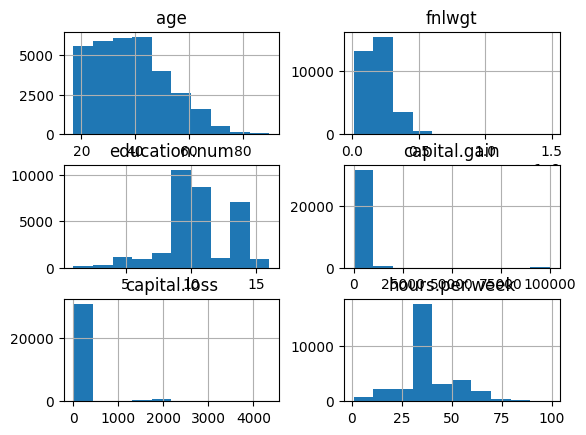

In [5]:
adult_data.hist()

Now, let us preprocess the dataset. To save time, we suggest applying the following preprocessing strategy:


| column             | preprocessing step      |
|--------------------|-------------------------|
| age                | MinMaxScaler            |
| workclass          | OneHotEncoder           |
| fnlwgt             | drop                    |
| education          | drop                    |
| education.num      | MinMaxScaler            |
| marital.status     | OneHotEncoder           |
| occupation         | OneHotEncoder           |
| relationship       | OneHotEncoder           |
| race               | OneHotEncoder           |
| sex                | OneHotEncoder           |
| capital.gain       | drop                    |
| capital.loss       | drop                    |
| hours.per.week     | StandardScaler          |
| native.country     | OneHotEncoder           |
| income             | LabelBinarizer          |

*Warning!* As we split the dataset into train and test sets, preprocessors defined on the training data might fail due to out-of-range or yet unseen categories of the test dataset. Hence, check [Sci-kit learn documentation](https://scikit-learn.org/stable/api/sklearn.preprocessing.html) how different preprocessors can handle such problems, and make sure that you use these techniques!



In [10]:
adult_data_proc = adult_data.drop(['fnlwgt', 'education', 'capital.gain', 'capital.loss'], axis=1)

In [11]:
X = adult_data_proc.drop('income', axis=1)
y = adult_data_proc['income']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
#TODO: create the preprocessing pipeline with proper transformers
#For example, standard scaler code can look like:
standard_scaler = Pipeline(
    steps=[
        ("standard_scaler", StandardScaler())
    ]
)

#Define the rest of the transformers:
one_hot_encoder = Pipeline(
    steps=[
        ("one_hot_encoder", OneHotEncoder(handle_unknown='ignore'))
    ]
)

min_max_scaler = Pipeline(
    steps=[
        ("min_max_scaler", MinMaxScaler())
    ]
)


########################
#The final preprocessor code:
preprocessor = ColumnTransformer([
        ("standard_scaler", standard_scaler, ["hours.per.week"]),
        ("one_hot_encoder", one_hot_encoder, ["workclass", "marital.status", "occupation", "relationship", "race", "sex", "native.country"]),
        ("min_max_scaler", min_max_scaler, ["age", "education.num"]),
    ]
)
X_train = preprocessor.fit_transform(X_train).toarray()
X_test = preprocessor.transform(X_test).toarray()

In [14]:
#TODO: also encode the y vector
lb = LabelBinarizer()
y_train = lb.fit_transform(y_train)
y_test = lb.transform(y_test)

**As we will have to adapt our neural network's input layer, let us check the shape of the matrix of the training data:**

In [15]:
X_train.shape

(26048, 89)

### 1.2 Defining and training a neural network for classification

For classification problems, we typically use cross-entropy loss functions (e.g., binary cross-entropy for two-class classification and categorical cross-entropy for multi-class classification) to measure how well the neural network classifies records. Moreover, neural network classifiers use the `sigmoid` activation (or its multi-dimensional version, the `softmax` function) in their *last layer*.

**Fill the missing lines of code, and implement a neural network for classification in imperative Pytorch:**

In [17]:
from tqdm.notebook import tqdm
from tqdm import trange
import torch.utils.data as data_utils

class ClassificationNet(nn.Module):
  def __init__(self):
    #calling constructor:
    super(ClassificationNet, self).__init__()
    #TODO: define fully connected layers: (89, 128) -> (128, 64) -> (64, 1)
    self.fc1 = nn.Linear(89, 128)
    self.fc2 = nn.Linear(128, 64)
    self.fc3 = nn.Linear(64, 1)
    #TODO: define a loss function:
    self.loss = nn.BCEWithLogitsLoss()

  def forward(self, x):
    #TODO: define forward pass with relu activations on the hidden layers
    x = torch.relu(self.fc1(x))
    x = torch.relu(self.fc2(x))
    #TODO: define output with a sigmoid activation
    # BCEWithLogitsLoss handles sigmoid internally, so we output logits
    x = self.fc3(x)
    return x

  def fit(self, x, y, optimizer, n_epochs):
    #TODO: write the training code, use a torch.utils.data.DataLoader
    #      with batch size of 1024
    self.train()
    tensor_x = torch.tensor(x).float()
    tensor_y = torch.tensor(y).float()
    dataset = data_utils.TensorDataset(tensor_x, tensor_y)
    loader = data_utils.DataLoader(dataset, batch_size=1024, shuffle=True)

    for i in trange(n_epochs):
      for batch_x, batch_y in loader:
        optimizer.zero_grad()
        output = self.forward(batch_x)
        loss = self.loss(output, batch_y)
        loss.backward()
        optimizer.step()

  def predict(self, x):
    self.eval()
    with torch.no_grad():
      output = torch.sigmoid(self.forward(x))
    return output

Note: While Pytorch originally had an imperative flavor on describing neural networks, nowadays, it also supports a more declarative approach.

(Tensorflow; however, originally supported the latter, which allowed it to compile the models into machine code providing a portable solution even for embedded devices. Today, both frameworks provides imperative and symbolic definitions; hence, in theory, there is no difference between the two frameworks. But it is still more likely that one will find Pytorch code in scientific papers, and Tensorflow codes in industrial applications.)

**Instantiate and train the defined neural network for 1 epoch!**

In [18]:
net = ClassificationNet()
optimizer = Adam(net.parameters(), lr=0.001)

#TODO: train the neural network for 1 epochs
net.fit(X_train, y_train, optimizer, n_epochs=1)

100%|██████████| 1/1 [00:00<00:00,  1.51it/s]


### 1.3 Evaluation

Let us make predictions with the trained neural network. To this end, we shall convert its output (which is a number in the $(0.0, 1.0)$ range due to the sigmoid activation) to `bool` values. We can simply do so by comparing the output to $0.5$: `y_pred = y_out>0.5`, where `y_out` is the output of the neural network.

As we have an obviously biased dataset, it is a good practice to check the resulting confusion matrix, instead of checking simple accuracies.

**Make the predictions and check the confusion matrix:**

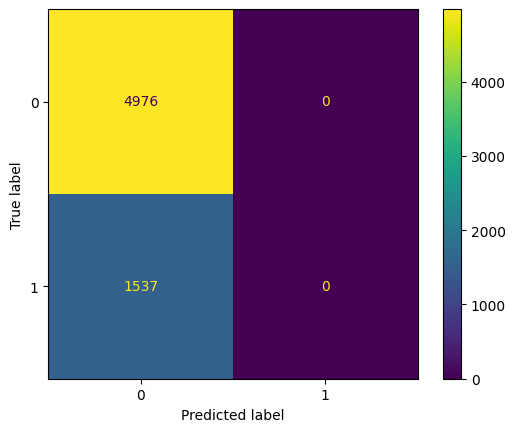

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#TODO: make predictions on the test set (prediction shall be stored in y_pred)
y_pred = net.predict(torch.tensor(X_test).float()) > 0.5

conf_matrix = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(conf_matrix).plot()

**Question 1.**

**What does the above confusion matrix mean? What is the problem with the neural network according to this confusion matrix?**

The confusion matrix reveals that the neural network has predicted all samples as belonging to the negative class (income <=50K). This results in 4976 correctly identified negative samples (TN) and 1537 missed positive samples (FN). Crucially, there are zero True Positives and zero False Positives, meaning the model never once predicted a sample to be positive. This indicates a severe issue, likely due to low number of epochs.



**Let us train the neural network further, e.g. for 99 more epochs! Check its performance on the confusion matrix!**

100%|██████████| 99/99 [00:36<00:00,  2.75it/s]


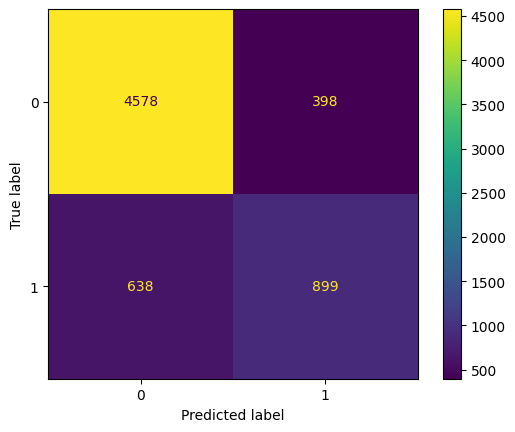

In [20]:
# TODO: train the neural network for 99 epochs, and check the results again!
net.fit(X_train, y_train, optimizer, n_epochs=99)

y_pred = net.predict(torch.tensor(X_test).float())>0.5
conf_matrix = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(conf_matrix).plot()

**Question 2.**

**How has training the neural network further influenced its classification performance?**

After 99 more epochs, the confusion matrix is [[4578, 398], [638, 899]]. The model now correctly identifies 899 positive samples (TP) and 4578 negative samples (TN). There are 398 False Positives and 638 False Negatives. This is a significant improvement as the model previously predicted no true positives. The increased training has enhanced its ability to classify both positive and negative instances.

---

## 2. A regression problem - Auto MPG

In this exercise, we will construct a neural network to predict automobile fuel consumption (measured in miles per gallon, MPG; higher values correspond to lower consumption). As our output will be a continuous value, this task corresponds to a regression.

### 2.1 Data preparation

**Let us load and check the first records of the dataset by running the code below.**

In [21]:
mpg_data = pd.read_csv("auto_mpg.csv")
mpg_data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


**Let us check the distribution of the numerical columns by calling the `hist()` function:**

array([[<Axes: title={'center': 'mpg'}>,
        <Axes: title={'center': 'cylinders'}>,
        <Axes: title={'center': 'displacement'}>],
       [<Axes: title={'center': 'weight'}>,
        <Axes: title={'center': 'acceleration'}>,
        <Axes: title={'center': 'model year'}>],
       [<Axes: title={'center': 'origin'}>, <Axes: >, <Axes: >]],
      dtype=object)

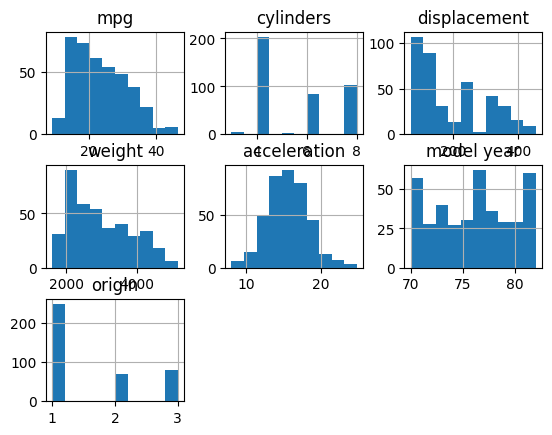

In [22]:
mpg_data.hist()

We will use the following preprocessing steps on the dataset:

| columns                  | preprocessing steps             |
|--------------------------|---------------------------------|
| mpg                      | StandardScaler                  |
| cylinders                | MinMaxScaler                    |
| displacement             | MinMaxScaler                    |
| horsepower               | MinMaxScaler                    |
| weight                   | MinMaxScaler                    |
| acceleration             | StandardScaler                  |
| model year               | MinMaxScaler                    |
| origin                   | drop                            |
| car name                 | drop                            |

Warning! This dataset contains some invalid data. For simplicity, we will drop these records now, according to the following strategy:
1. Replace `"?"` entries with `np.nan`'s.
2. Drop those *rows* from the DataFrame that contains *any* `nan` value.

In [23]:
# Drop unnecessary columns and rows
mpg_data_proc = mpg_data.drop(["origin", "car name"], axis=1)
mpg_data_proc = mpg_data_proc.replace("?", np.nan)
mpg_data_proc = mpg_data_proc.dropna()
mpg_data_proc["horsepower"] = mpg_data_proc["horsepower"].astype(float)

In [24]:
X = mpg_data_proc.drop("mpg", axis=1)
y = mpg_data_proc["mpg"]

#for manual testing, we save a record:
x_test_vector = X.loc[42]
y_test_vector = y.loc[42]
#and we remove it from the dataset:
X = X.drop(index=42)
y = y.drop(index=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [25]:
minmax = Pipeline(
    steps=[
        ("minmax", MinMaxScaler(clip=True))
    ]
)
standard = Pipeline(
    steps=[
        ("standard", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    [
        ("minmax", minmax, ["cylinders", "displacement", "horsepower", "weight", "model year"]),
        ("standard", standard, ["acceleration"])
    ]
)

label_scaler = StandardScaler()

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)
y_train = label_scaler.fit_transform(np.array(y_train).reshape(-1, 1))
y_test = label_scaler.transform(np.array(y_test).reshape(-1, 1))

In [26]:
X_train.shape

(312, 6)

### 2.2 Training a neural network for regression

For regression problems, we generally use "distance metrics" (e.g., mean squared error (MSE) or root mean squared error (RMSE)) to measure how well the neural network predicts values. On the *last layer* of the neural network, we typically use a linear or ReLU (rectified linear unit) activation function, depending on the target value's range. If the output is non-negative, ReLU activation is widely used; when the output can take arbitrary values, we usually use linear activation.

**A couple of lines of code are missing from the class below. Please, fill the missing parts as needed.**

In [27]:
class RegressionNet(nn.Module):
  def __init__(self):
    super(RegressionNet, self).__init__()
    self.fc1 = nn.Linear(6, 256)
    self.fc2 = nn.Linear(256, 64)
    self.fc3 = nn.Linear(64, 1)
    self.loss = nn.MSELoss()

  def forward(self, x):
    x = torch.relu(self.fc1(x))
    x = torch.relu(self.fc2(x))
    x = self.fc3(x)
    return x

  def fit(self, x, y, optimizer, n_epochs, verbose=True):
    self.train()
    rangeing = trange(n_epochs) if verbose else range(n_epochs)
    data_loader = torch.utils.data.DataLoader(list(zip(x,y)), batch_size=128, shuffle=True)
    avg_loss = 0
    for i in rangeing:
      for batch_x, batch_y in data_loader:
        optimizer.zero_grad()
        output = self.forward(batch_x)
        loss = self.loss(output, batch_y)
        loss.backward()
        optimizer.step()
        avg_loss += loss.detach().clone().float()
    return avg_loss / (len(data_loader) * n_epochs)

  def predict(self, x):
    self.eval()
    with torch.no_grad():
      output = self.forward(x)
    return output

  def fit_with_evaluation(self, x_train, y_train, x_test, y_test, optimizer, n_epochs):
    train_loss, test_loss = [], []
    for i in trange(n_epochs):
      loss = self.fit(x_train, y_train, optimizer, 1, verbose=False)
      train_loss.append(loss)
      self.eval()
      with torch.no_grad():
        output = self.forward(x_test)
        test_loss.append(self.loss(output, y_test).item())
      self.train()
    return train_loss, test_loss

**Run the code below to train the neural network.**

In [28]:
model = RegressionNet()
optimizer = Adam(model.parameters(), lr=0.0075)
train_loss, test_loss = model.fit_with_evaluation(torch.tensor(X_train).float(),
                                                  torch.tensor(y_train).float(),
                                                  torch.tensor(X_test).float(),
                                                  torch.tensor(y_test).float(),
                                                  optimizer,
                                                  500)

100%|██████████| 500/500 [00:07<00:00, 63.50it/s] 


Now, let us check the output of the neural network.
To this end, we will feed in a test vector. As we have to preprocess the inputs; firstly, print its human readable form, and then let us see the prediction of the neural network!

**Run the following cells**

In [29]:
#test input (in human readable form):
x_test_vector

,42
cylinders,8.0
displacement,383.0
horsepower,180.0
weight,4955.0
acceleration,11.5
model year,71.0


In [30]:
#expected output:
y_test_vector

np.float64(12.0)

In [31]:
#convert the input:
x_test_processed = preprocessor.transform(pd.DataFrame([x_test_vector]))

#prediction:
model.eval()
y_test_output = model.predict(torch.tensor(x_test_processed).float())
y_test_output

tensor([[-1.2487]])

This output is obviously not an MPG value *yet*. As you can remember, we have also scaled the labels with a standard scaler:

$y_s = \frac{y-\mu_y}{\sigma_y}$.

Hence, we shall scale the result back:

$y = y_s\sigma_s + \mu_s$

**Compute $y$ accordingly:**

In [32]:
# Inverted scaler code
y_test_output_np = y_test_output.cpu().numpy()
y_original = label_scaler.inverse_transform(y_test_output_np)
print(f"Predicted MPG: {y_original[0][0]}, Actual MPG: {y_test_vector}")

Predicted MPG: 13.708608627319336, Actual MPG: 12.0


As you can see, the result is relatively precise. By plotting the learning curves, let us check how the model performed during the training process!

**Run the following code!**

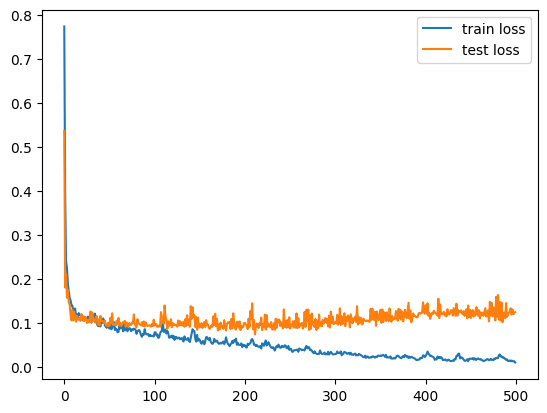

In [33]:
import matplotlib.pyplot as plt

plt.plot(train_loss, label="train loss")
plt.plot(test_loss, label="test loss")
plt.legend()

As you can see, despite having an improving train loss, the test loss slightly increases. It is a typical overfitting problem.

## Homework assignment

There are numerous ways to avoid overfitting of neural networks. As a homework assignment, implement at least one of the overfitting-prevention methods to improve the model's prediction capabilities:
1. Dropout
2. Regularization
3. Early stopping

(You can modify the codes below if necessarry.)

In [34]:
#TODO: Implement at least one overfitting avoiding method!
from tqdm.notebook import tqdm
from tqdm import trange

class RegressionNetNoOverfit(nn.Module):
  def __init__(self):
    #calling constructor:
    super(RegressionNetNoOverfit, self).__init__()
    self.fc1 = nn.Linear(6, 256)
    self.fc2 = nn.Linear(256, 64)
    self.fc3 = nn.Linear(64, 1)
    self.dropout = nn.Dropout(0.2) # Adding Dropout layer
    #TODO: define a loss function:
    self.loss = nn.MSELoss()

  def forward(self, x):
    x = torch.relu(self.fc1(x))
    x = torch.relu(self.fc2(x))
    x = self.dropout(x) # Apply dropout
    #TODO: define appropriate output
    # The output 'y' is standardized and can be negative, so a linear activation is appropriate.
    x = self.fc3(x)
    return x

  def fit(self, x, y, optimizer, n_epochs, verbose=True):
    self.train()
    rangeing = trange(n_epochs) if verbose else range(n_epochs)
    data_loader = torch.utils.data.DataLoader(
        list(zip(x,y)),
        batch_size=128,
        shuffle=True
    )

    avg_loss = 0
    for i in rangeing:
      for batch_x, batch_y in data_loader:
        optimizer.zero_grad()
        output = self.forward(batch_x)
        loss = self.loss(output, batch_y)
        loss.backward()
        optimizer.step()
        avg_loss += loss.detach().clone().float()
    return avg_loss/len(data_loader)

  def predict(self, x):
    self.eval()
    with torch.no_grad():
      output = self.forward(x)
    return output

  def fit_with_evaluation(self, x_train, y_train,
                          x_test, y_test,
                          optimizer, n_epochs):
    train_loss, test_loss = [], []
    for i in trange(n_epochs):
      loss = self.fit(x_train, y_train, optimizer, 1, verbose=False)
      train_loss.append(loss)
      self.eval()
      with torch.no_grad():
        output = self.forward(x_test)
        test_loss.append(self.loss(output, y_test).numpy())
      self.train()
    return train_loss, test_loss

**Train the above network:**

In [35]:
model = RegressionNetNoOverfit()
optimizer = Adam(model.parameters(), lr=0.0075)
train_loss, test_loss = model.fit_with_evaluation(torch.tensor(X_train).float(),
                                                  torch.tensor(y_train).float(),
                                                  torch.tensor(X_test).float(),
                                                  torch.tensor(y_test).float(),
                                                  optimizer,
                                                  500)

100%|██████████| 500/500 [00:05<00:00, 85.78it/s]


**Check the learning curves**

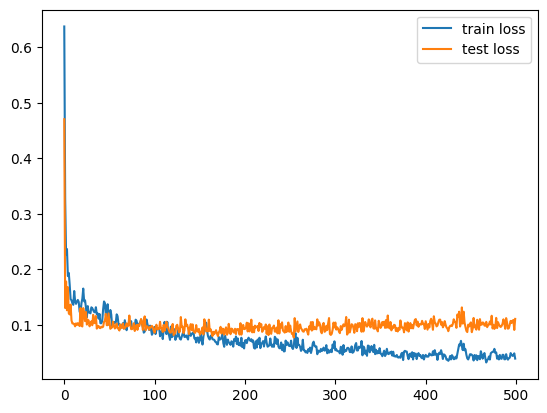

In [36]:
import matplotlib.pyplot as plt

plt.plot(train_loss, label="train loss")
plt.plot(test_loss, label="test loss")
plt.legend()